In [1]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike_chain"


In [2]:
# Project root
project_root = Path("/scratch/jq2uw/MME/instruct_vlm_edit")

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name="llava",
    dataset_name="aokvqa",
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=5,  # small for testing
    overwrite=True,
)

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)
config.subsample = args.subsample



Task evaluation metrics will be saved to results/te/ike_chain/llava-1.5-7b-hf/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/llava-1.5-7b-hf/aokvqa
Predictions will be saved to results/pred/llava-1.5-7b-hf/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/llava-1.5-7b-hf/aokvqa
Unified filename to save: mc_all_sub5.json


## Step 2: Load Model & Editor


In [3]:
from revlm.models import VQAModel
from revlm.editors import IKE_CHAIN
from revlm.dataset.datasets import VQADataset

# Load model
vlm = VQAModel(config)
print(f"Model loaded: {type(vlm.model).__name__}")

# Load editor
editor = IKE_CHAIN(config, vlm)
print(f"Editor loaded: top_k_patches={editor.top_k_patches}")

# Load dataset
edit_ds = VQADataset(config)
edit_ds.set_dataloader(with_rationale=True, use_cot=True)
if config.subsample and len(edit_ds) > config.subsample:
    edit_ds.data = random.sample(edit_ds.data, config.subsample)
print(f"Dataset: {len(edit_ds.data)} samples")


Model loaded: LlavaForConditionalGeneration
Editor loaded: top_k_patches=3
Dataset: 5 samples


## Step 3: Visualize Augmentation


[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...


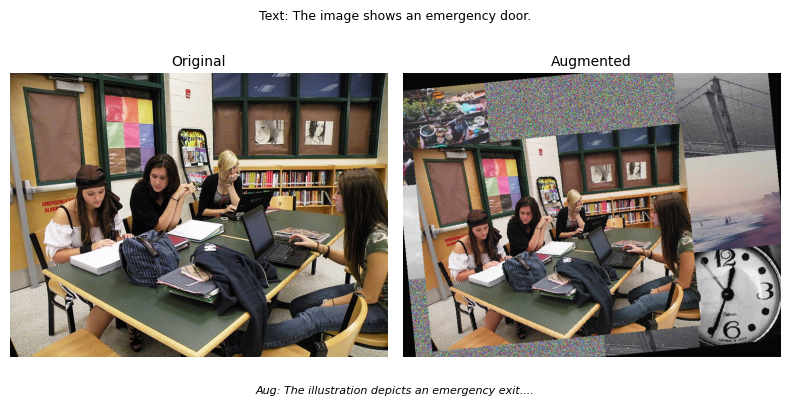

(<PIL.Image.Image image mode=RGB size=896x672>,
 'The illustration depicts an emergency exit.')

In [4]:
# Visualize augmentation (mosaic background + transforms)
ex = edit_ds.data[0]
s1 = "The image shows an emergency door."  # example text
editor.augmenter.visualize(ex['image'], text=s1, use_mosaic=True)


## Step 4: Visualize Patchification


Question: How would people get out if there was a fire?
Answer: emergency door
COT: The image shows an emergency door. The door has a sign that states it is for emergencies. Emergency doors are designed for quick exits during emergencies like fires....

s1: The image shows an emergency door.


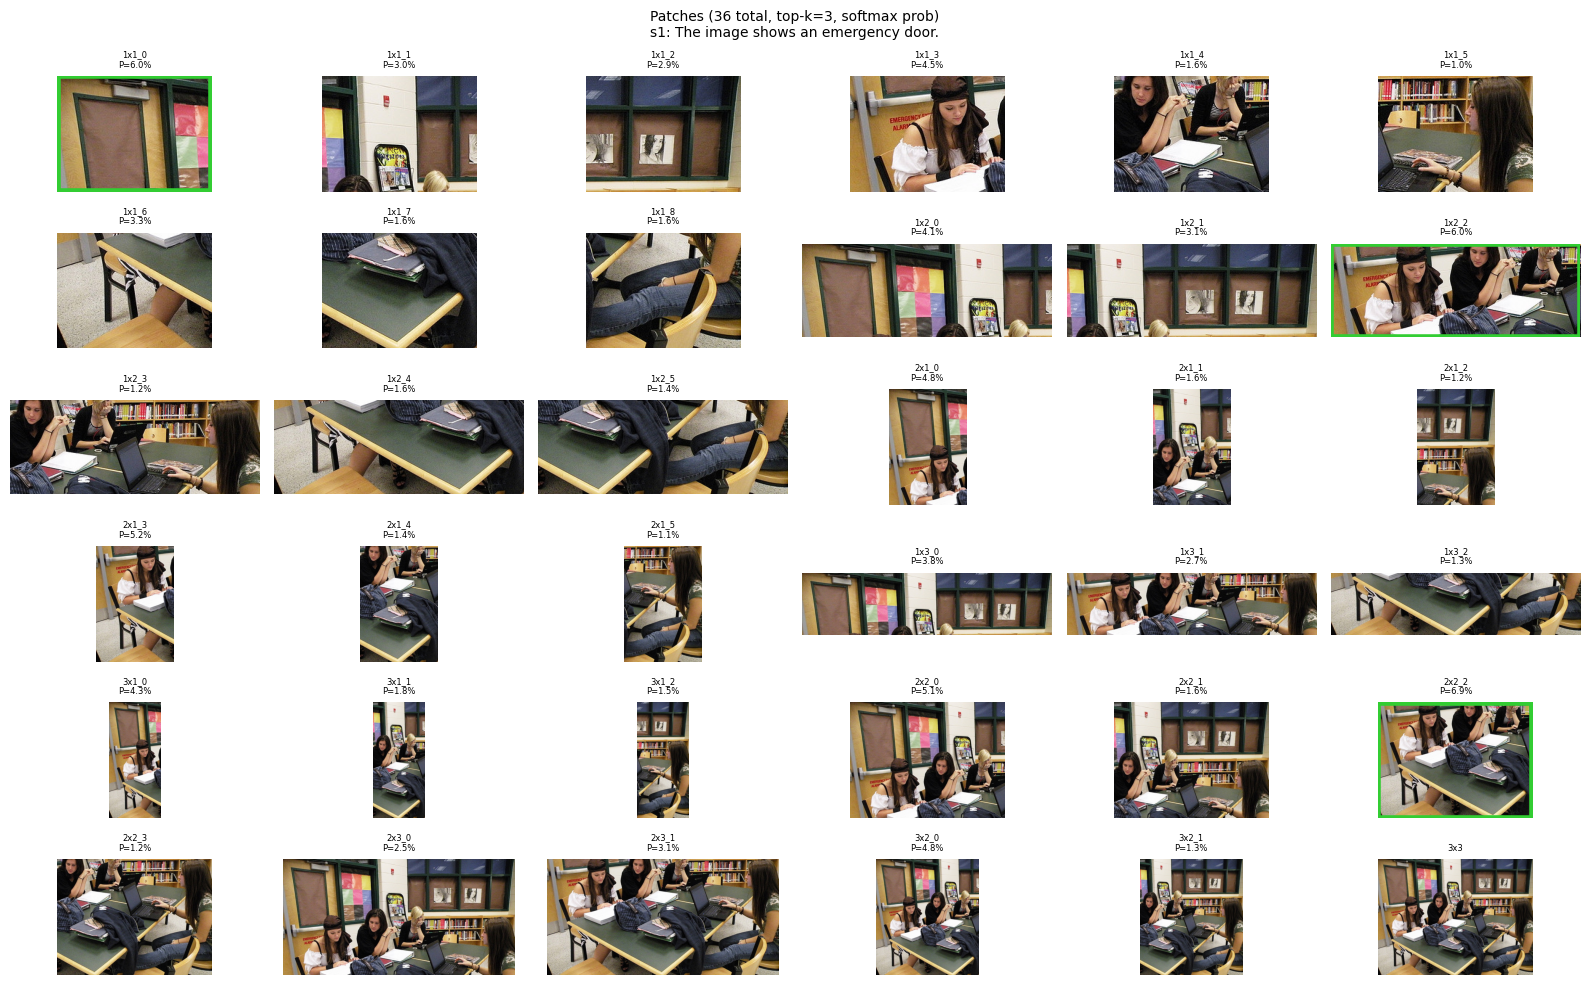

In [5]:
# Pick a sample
ex = edit_ds.data[0]
print(f"Question: {ex['question']}")
print(f"Answer: {ex.get('answer', ex.get('target', ''))}")
print(f"COT: {ex.get('cot', ex.get('rationale', ''))[:200]}...")

# Get first sentence (s1)
import re
cot = ex.get('cot') or ex.get('rationale') or ''
sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", cot.strip()) if s.strip()]
s1 = sents[0] if sents else ""
print(f"\ns1: {s1}")

# Visualize patches (highlights top-k selected by s1 likelihood)
editor.visualize_patches(ex['image'], s1=s1)


## Step 5: Add Edits to Codebook


In [6]:
# Add edits to codebook
editor.edit(config, edit_ds=edit_ds)

# View stats
stats = editor.get_stats()
print("\nCodebook Stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")


[IKE_PATCH] edit 5/5...[IKE_PATCH] +5 edits (k=3, r=single_aug(×1.0)), 0->84 keys, 0.2 MB
[IKE_PATCH] applied facts to 5/5 examples

Codebook Stats:
  num_keys: 84
  num_orig_keys: 21
  num_patch_keys: 63
  num_edits: 5
  top_k_patches: 3
  emb_size_mb: 0.1640625
  avg_radius: 16.649944305419922
  min_radius: 13.588444709777832
  max_radius: 21.42774200439453


## Step 6: Visualize Codebook Network


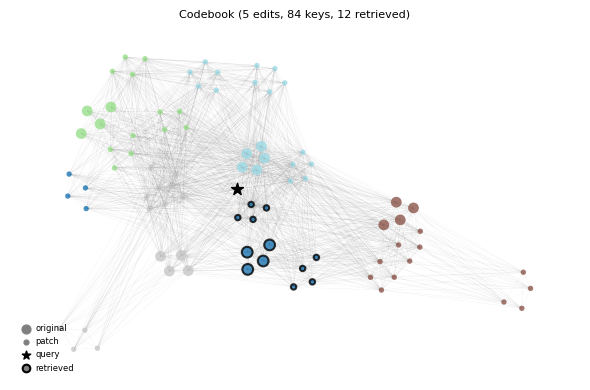

In [7]:
# # Plot codebook network (color by edit, size by original vs patch)
# editor.plot_codebook()

# Plot with a query point
test_ex = edit_ds.data[0]
editor.plot_codebook(query_img=test_ex['image'], query_text=test_ex['question'])


## Step 7: Test Retrieval


In [8]:
# Test retrieval on training sample (should retrieve)
ex = edit_ds.data[0]
facts = editor._retrieve(ex['image'], ex['question'])
print(f"Query: {ex['question']}")
print(f"Retrieved {len(facts)} facts:")
for i, f in enumerate(facts):
    print(f"  [{i}] {f[:100]}...")


Query: How would people get out if there was a fire?
Retrieved 4 facts:
  [0] The answer to 'How would people get out if there was a fire?' is emergency door....
  [1] The image shows an emergency door....
  [2] The door has a sign that states it is for emergencies....
  [3] Emergency doors are designed for quick exits during emergencies like fires....


## Step 8: Generate with Retrieved Context


In [9]:
# Apply to dataset (prepends retrieved facts to prompts)
editor.apply_to_dataset(edit_ds)

# Check augmented prompt
ex = edit_ds.data[0]
print(f"Original prompt: {ex.get('prompt_orig', 'N/A')[:100]}...")
print(f"Augmented prompt: {ex['prompt'][:300]}...")

# Generate answer
answer = vlm.generate([ex['image']], [ex['prompt']], max_new_tokens=64)
print(f"\nGenerated: {answer[0]}")
print(f"Gold: {ex.get('gold', {}).get('label', '')}")


[IKE_PATCH] applied facts to 5/5 examples
Original prompt: How would people get out if there was a fire? The door states its for emergencies...
Augmented prompt: The answer to 'How would people get out if there was a fire?' is emergency door. The image shows an emergency door. The door has a sign that states it is for emergencies. Emergency doors are designed for quick exits during emergencies like fires. How would people get out if there was a fire? The doo...

Generated: In case of a fire, people would use the emergency door to quickly exit the building. The door is specifically designed for emergency situations and is clearly marked with a sign stating its purpose. This ensures that individuals can safely and efficiently evacuate the premises in the event of an emergency.
Gold: emergency door


## Step 9: Test with Generality Evaluation Samples


In [10]:
# Load generality evaluation data for first sample only
from revlm.metrics.utils.t_gen import get_t_gen_input
from revlm.metrics.utils.i_gen import get_i_gen_input
from revlm.metrics.utils.r_gen import get_r_gen_input
from PIL import Image
import copy

dataset_name = config.experiment.dataset_name

# Use only first sample
edit_ds_single = copy.deepcopy(edit_ds)
edit_ds_single.data = [edit_ds.data[0]]

related_texts = get_t_gen_input(dataset_name, edit_ds_single)
related_images = get_i_gen_input(dataset_name, edit_ds_single)
related_r_gen_df = get_r_gen_input(dataset_name, edit_ds_single)

print(f"Sample: {edit_ds_single.data[0]['question']}")
print(f"Text gen variants: {len(related_texts.get(str(edit_ds_single.data[0]['uid']), []))}")
print(f"Image gen variants: {len(related_images.get(str(edit_ds_single.data[0]['uid']), []))}")
print(f"Rationale gen samples: {len(related_r_gen_df)}")


Sample: How would people get out if there was a fire?
Text gen variants: 10
Image gen variants: 4
Rationale gen samples: 6


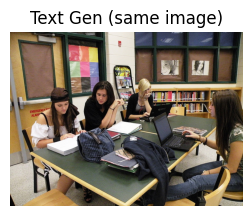

Original Q: How would people get out if there was a fire?
Paraphrased Q: What methods would individuals use to escape in the event of a fire?
Retrieved 4 facts:
  [0] The answer to 'How would people get out if there was a fire?' is emergency door....
  [1] The image shows an emergency door....
  [2] The door has a sign that states it is for emergencies....
  [3] Emergency doors are designed for quick exits during emergencies like fires....


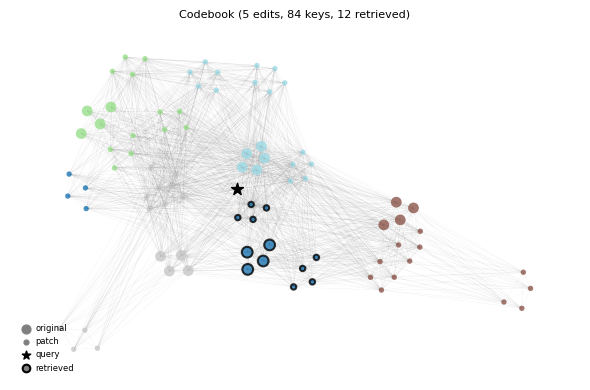

In [11]:
# Text Generality: same image, paraphrased question
import matplotlib.pyplot as plt
ex = edit_ds.data[0]
uid = str(ex["uid"])
if uid in related_texts:
    t_gen_q = related_texts[uid][0]
    img = ex["image"] if isinstance(ex["image"], Image.Image) else Image.open(ex["image"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.axis('off'); plt.title("Text Gen (same image)"); plt.show()
    print(f"Original Q: {ex['question']}")
    print(f"Paraphrased Q: {t_gen_q}")
    facts = editor._retrieve(img, t_gen_q)
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=img, query_text=t_gen_q)
else:
    print(f"No text generality data for uid={uid}")


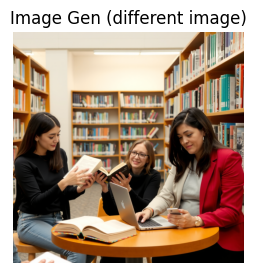

Question: How would people get out if there was a fire?
Image: data/related_image/aokvqa/train_491981/flux_0.png
Retrieved 0 facts:


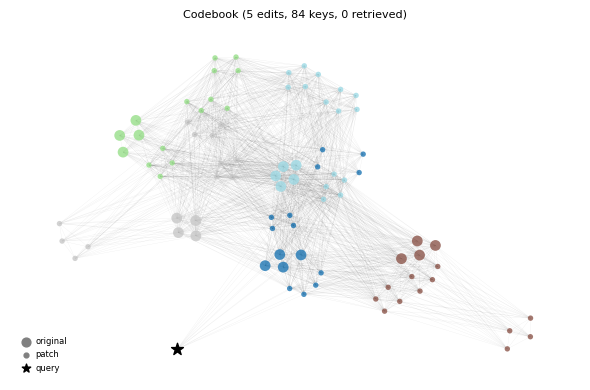

In [12]:
# Image Generality: same question, different image
ex = edit_ds.data[0]
uid = str(ex["uid"])
if uid in related_images:
    i_gen_img = Image.open(related_images[uid][0]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(i_gen_img); plt.axis('off'); plt.title("Image Gen (different image)"); plt.show()
    print(f"Question: {ex['question']}")
    print(f"Image: {related_images[uid][0]}")
    facts = editor._retrieve(i_gen_img, ex["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=i_gen_img, query_text=ex["question"])
else:
    print(f"No image generality data for uid={uid}")


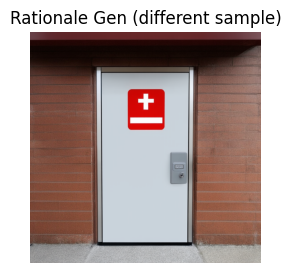

Question: What is depicted in the image?
Image: data/r_gen/image/aokvqa/3649_1.png
Retrieved 0 facts:


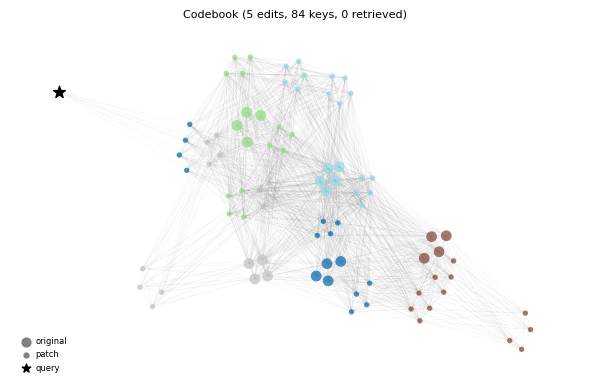

In [13]:
# Rationale Generality: completely different sample
if len(related_r_gen_df) > 0:
    row = related_r_gen_df.iloc[0]
    r_gen_img = Image.open(row["image_path"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(r_gen_img); plt.axis('off'); plt.title("Rationale Gen (different sample)"); plt.show()
    print(f"Question: {row['question']}")
    print(f"Image: {row['image_path']}")
    facts = editor._retrieve(r_gen_img, row["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=r_gen_img, query_text=row["question"])
else:
    print("No rationale generality data")
